In [ ]:
import torch
from torch.utils.data import Dataset,DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, roc_curve
import random
import matplotlib.pyplot as plt
import os
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [2]:
MODEL = "NaturalAntibody/nanoBERT"
train_csv = "data/Round3/90/changed_train_seqs_new.csv"
val_csv = "data/Round3/90/changed_val_seqs_validation.csv"
test_csv = "data/Round3/90/changed_test_seqs_new.csv"
val_test_csv = "data/Round3/90/changed_val_seqs_test.csv"

seq_col = "Sequence"
label_col = "Label"
cluster_col = "Cluster_number"
max_len = 160
num_labels = 2
epochs = 10
learning_rate = 2e-5
batch_size = 32
space_separated = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = AutoTokenizer.from_pretrained(MODEL, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels).to(device)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at NaturalAntibody/nanoBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
for param in model.base_model.parameters():
    param.requires_grad = False

opt = AdamW((param for param in model.parameters() if param.requires_grad), lr=learning_rate)

In [4]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

train_seqs = train_df[seq_col].astype(str).tolist()
train_labels = train_df[label_col].astype(int).tolist()
val_seqs = val_df[seq_col].astype(str).tolist()
val_labels = val_df[label_col].astype(int).tolist()

In [5]:
class DS(Dataset):
    def __init__(self, seqs, labels, clusters = None, cluster_key ="Cluster_number"):
        self.seqs = seqs
        self.labels = labels
        self.clusters = clusters
        self.cluster_key = cluster_key

        if self.clusters is not None:
            assert len(self.seqs) == len(self.clusters), "The number of sequences and clusters must be the same."

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        s = self.seqs[idx]
        if space_separated:
            s = " ".join(list(s))
            
        x = tok(
            s,
            truncation=True,
            max_length=max_len,
            padding="max_length",
            return_tensors="pt",
        )
        x = {k: v.squeeze(0) for k, v in x.items()}
        x["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.clusters is not None:
            x[self.cluster_key] = torch.tensor(self.clusters[idx], dtype=torch.long)
        return x

In [6]:
def eval_metrics(model, dl):
    model.eval()
    all_scores = []
    all_labels = []
    with torch.no_grad():
        for b in dl:
            b = {k: v.to(device) for k, v in b.items()}
            outputs = model(input_ids=b["input_ids"], attention_mask=b["attention_mask"])
            logits = outputs.logits
            scores = torch.softmax(logits, dim=-1)[:, 1]
            all_scores.append(scores.cpu())
            all_labels.append(b["labels"].cpu())
    all_scores = torch.cat(all_scores).numpy()
    all_labels = torch.cat(all_labels).numpy()

    all_preds = (all_scores > 0.5).astype(int)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1


In [7]:
g = torch.Generator()
g.manual_seed(42)

train_dl = DataLoader(DS(train_seqs, train_labels), batch_size=batch_size, shuffle=True, generator = g)
val_dl = DataLoader(DS(val_seqs, val_labels), batch_size=batch_size, shuffle=False)

In [8]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=np.array(train_labels)
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)

Class weights: 

tensor([1.0170, 0.9835], device='cuda:0')


In [ ]:
best_val_prec = -1.0
best_epoch = -1
patience = 4
counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for b in train_dl:
        b = {k: v.to(device) for k, v in b.items()}
        opt.zero_grad()

        labels = b["labels"]

        outputs = model(
            input_ids=b["input_ids"],
            attention_mask=b["attention_mask"]
        )

        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    train_loss = total_loss / max(1, len(train_dl))

    val_acc, val_prec, val_rec, val_f1 = eval_metrics(model, val_dl)

    print(
        f"Epoch {epoch+1}: "
        f"train loss {train_loss:.4f}, "
        f"val acc {val_acc:.4f}, "
        f"val prec {val_prec:.4f}, "
        f"val rec {val_rec:.4f}, "
        f"val f1 {val_f1:.4f}"
    )

    if val_prec > best_val_prec:
        best_val_prec = val_prec
        best_epoch = epoch + 1
        counter = 0
        torch.save(model.state_dict(), "best_nanobert_frozen_weighted_90.pt")
        print(f"Saved best model at epoch {best_epoch} with val_prec={best_val_prec:.4f}")
    else:
        counter +=1
        print(f"No improvement. Patience counter: {counter}/ {patience}")
    if counter >= patience:
        print("Early stopping triggered!!!")
        break

print(f"Best epoch: {best_epoch}, best val_prec: {best_val_prec:.4f}")

Epoch 1: train loss 0.6865, val acc 0.5648, val prec 0.5654, val rec 0.6508, val f1 0.6051
Saved best model at epoch 1 with val_prec=0.5654


Epoch 2: train loss 0.6830, val acc 0.5681, val prec 0.5765, val rec 0.5922, val f1 0.5842
Saved best model at epoch 2 with val_prec=0.5765


Epoch 3: train loss 0.6825, val acc 0.5711, val prec 0.5620, val rec 0.7383, val f1 0.6382
No improvement. Patience counter: 1/ 4


Epoch 4: train loss 0.6821, val acc 0.5751, val prec 0.5665, val rec 0.7271, val f1 0.6368
No improvement. Patience counter: 2/ 4


Epoch 5: train loss 0.6819, val acc 0.5721, val prec 0.5673, val rec 0.6954, val f1 0.6248
No improvement. Patience counter: 3/ 4


Epoch 6: train loss 0.6816, val acc 0.5758, val prec 0.5774, val rec 0.6416, val f1 0.6078
Saved best model at epoch 6 with val_prec=0.5774


Epoch 7: train loss 0.6814, val acc 0.5765, val prec 0.5716, val rec 0.6923, val f1 0.6262
No improvement. Patience counter: 1/ 4


Epoch 8: train loss 0.6816, val acc 0.5709, val prec 0.5810, val rec 0.5830, val f1 0.5820
Saved best model at epoch 8 with val_prec=0.5810


Epoch 9: train loss 0.6813, val acc 0.5730, val prec 0.5794, val rec 0.6082, val f1 0.5934
No improvement. Patience counter: 1/ 4


Epoch 10: train loss 0.6816, val acc 0.5742, val prec 0.5662, val rec 0.7227, val f1 0.6349
No improvement. Patience counter: 2/ 4
Best epoch: 8, best val_prec: 0.5810


In [10]:
model.load_state_dict(torch.load("best_nanobert_frozen_weighted_90.pt", map_location=device))
model.to(device)
model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(25, 320, padding_idx=1)
      (position_embeddings): Embedding(202, 320, padding_idx=1)
      (token_type_embeddings): Embedding(1, 320)
      (LayerNorm): LayerNorm((320,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=320, out_features=320, bias=True)
              (key): Linear(in_features=320, out_features=320, bias=True)
              (value): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=320, out_features=320, bias=True)
              

In [11]:
test_df = pd.read_csv(test_csv)
val_test_df = pd.read_csv(val_test_csv)

test_seqs = test_df[seq_col].astype(str).tolist()
test_labels = test_df[label_col].astype(int).tolist()
test_cluster_ids, _ = pd.factorize(test_df[cluster_col].astype(str))
test_cluster_ids = test_cluster_ids.tolist()
test_dl = DataLoader(DS(test_seqs, test_labels, clusters=test_cluster_ids, cluster_key="Cluster_number"), batch_size=batch_size, shuffle=False)

val_test_seqs = val_test_df[seq_col].astype(str).tolist()
val_test_labels = val_test_df[label_col].astype(int).tolist()
val_test_cluster_ids, _ = pd.factorize(val_test_df[cluster_col].astype(str))
val_test_cluster_ids = val_test_cluster_ids.tolist()
val_test_dl = DataLoader(DS(val_test_seqs, val_test_labels, clusters=val_test_cluster_ids, cluster_key="Cluster_number"), batch_size=batch_size, shuffle=False)

In [ ]:
def diversity_at_k (cluster_ids, scores, k=100):
    cluster_ids = np.asarray(cluster_ids)   
    scores = np.asarray(scores) 
    k = min(k, len(scores))
    top_idx = np.argsort(scores)[::-1][:k]
    return len(np.unique(cluster_ids[top_idx]))
    

In [13]:
def metrics_at_k(all_labels, all_scores, k):
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)

    sorted_indices = np.argsort(all_scores)[::-1]
    k_eff = min(k, len(all_labels))
    top_k_indices = sorted_indices[:k_eff]

    top_k_labels = all_labels[top_k_indices]
    
    num_pos_total = all_labels.sum()
    num_pos_top_k = top_k_labels.sum()

    precision_at_k = num_pos_top_k / max(1, k_eff)
    recall_at_k = num_pos_top_k / max(1, num_pos_total)

    prevalence = num_pos_total / len(all_labels)
    ef_at_k = precision_at_k / max(prevalence, 1e-12)

    return precision_at_k, recall_at_k, ef_at_k


In [14]:
def evaluate_split(model, dl, device, k=100, cluster_key=None):
    model.eval()

    all_labels = []
    all_preds = []
    all_scores = []
    all_clusters = [] if cluster_key is not None else None

    with torch.no_grad():
        for b in dl:
            if cluster_key is not None:
                if cluster_key not in b:
                    raise KeyError(f"Key {cluster_key} not found in the batch.")
                clusters = b[cluster_key]
                all_clusters.extend(clusters.cpu().numpy())

            labels = b["labels"].to(device)

            inputs = {
                kk: vv.to(device)
                for kk, vv in b.items()
                if kk not in [cluster_key, "labels"]
            }

            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_scores.extend(probs[:, 1].cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_scores)

    precision_1, recall_1, _ = precision_recall_curve(all_labels, all_scores)
    pr_auc = auc(recall_1, precision_1)

    precision_at_k, recall_at_k, ef_at_k = metrics_at_k(all_labels, all_scores, k)
    precision_at_1000, _, _ = metrics_at_k(all_labels, all_scores, 1000)

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        f"precision@{k}": precision_at_k,
        f"recall@{k}": recall_at_k,
        f"ef@{k}": ef_at_k,
        "precision@1000": precision_at_1000
    }

    if cluster_key is not None:
        div_at_k = diversity_at_k(all_clusters, all_scores, k=k)
        metrics[f"diversity@{k}"] = div_at_k

    return {
        "metrics": metrics,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "scores": np.array(all_scores),
    }

In [15]:
best_path = "best_nanobert_frozen_weighted_90.pt"

best_model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels)
best_model.load_state_dict(torch.load(best_path, map_location=device))
best_model.to(device)
best_model.eval()

test_results = evaluate_split(best_model, test_dl, device, k=100, cluster_key="Cluster_number")
val_test_results = evaluate_split(best_model, val_test_dl, device, k=100, cluster_key="Cluster_number")

print("TEST METRICS")
for k, v in test_results["metrics"].items():
    print(f"{k}: {v:.4f}")

print("\nVAL_TEST METRICS")
for k, v in val_test_results["metrics"].items():
    print(f"{k}: {v:.4f}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at NaturalAntibody/nanoBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TEST METRICS
accuracy: 0.5771
precision: 0.5869
recall: 0.6073
f1: 0.5969
roc_auc: 0.6095
pr_auc: 0.6135
precision@100: 0.7800
recall@100: 0.0030
ef@100: 1.5127
precision@1000: 0.7250
diversity@100: 96.0000

VAL_TEST METRICS
accuracy: 0.5635
precision: 0.5712
recall: 0.5945
f1: 0.5826
roc_auc: 0.5924
pr_auc: 0.5972
precision@100: 0.7600
recall@100: 0.0259
ef@100: 1.4830
precision@1000: 0.6230
diversity@100: 98.0000


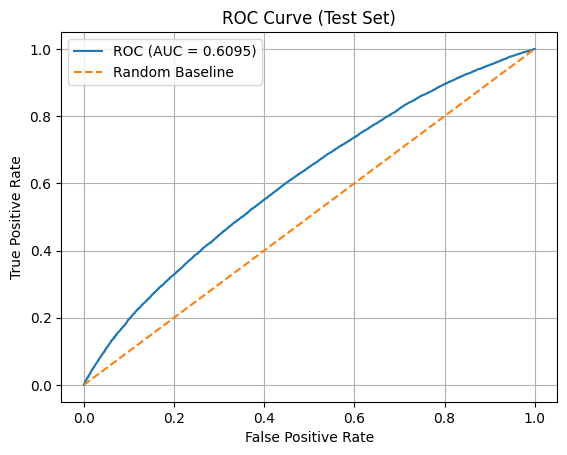

In [ ]:
best_model.eval()
all_labels = []
all_scores = []

with torch.no_grad():
    for b in test_dl:
        labels = b["labels"].to(device)

        inputs = {
            kk: vv.to(device)
            for kk, vv in b.items()
            if kk not in ["Cluster_number", "labels"]
        }

        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        all_labels.extend(labels.cpu().numpy())
        all_scores.extend(probs[:, 1].cpu().numpy())

fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.grid(True)
plt.show()